# Chapter 3 — Analytic Geometry
## Mathematics for Machine Learning (Deisenroth, Faisal & Ong)
### Complete Exercise Solutions (3.1 – 3.10)

> **Note on Source Material:**  
> All exercises and theoretical formulations in this notebook are taken directly from the textbook  
> **"Mathematics for Machine Learning"** by Marc Peter Deisenroth, A. Aldo Faisal, and Cheng Soon Ong (Cambridge University Press).


---


In [1]:
import numpy as np
from numpy.linalg import norm, det, inv
import sympy as sp
from sympy import Matrix, symbols, Rational, sqrt, simplify, eye, cos, sin, pi, pprint
from sympy import init_printing
init_printing(use_unicode=True)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
np.set_printoptions(precision=4, suppress=True)

---
## Exercise 3.1 — Inner Product Verification

Show that $\langle x, y \rangle := x_1 y_1 - (x_1 y_2 + x_2 y_1) + 2 x_2 y_2$ is an inner product on $\mathbb{R}^2$.

### Solution 3.1

We can write this as $\langle x, y \rangle = x^\top A y$ where $A = \begin{pmatrix} 1 & -1 \\ -1 & 2 \end{pmatrix}$.

An inner product requires $A$ to be **symmetric positive definite**:

1. **Bilinearity:** $\langle x, y \rangle = x^\top A y$ is bilinear by construction. ✓

2. **Symmetry:** $A = A^\top$ since $A_{12} = A_{21} = -1$. ✓

3. **Positive definiteness:** Check eigenvalues or leading principal minors:
   - $A_{11} = 1 > 0$ ✓
   - $\det(A) = 1 \cdot 2 - (-1)^2 = 1 > 0$ ✓
   
   By Sylvester's criterion, $A$ is positive definite. ✓

In [2]:
print("=== Exercise 3.1 ===")
A = sp.Matrix([[1, -1], [-1, 2]])
print("A =")
pprint(A)
print(f"\nSymmetric? {A == A.T}")
print(f"det(A) = {A.det()} > 0? {A.det() > 0}")
print(f"Eigenvalues: {A.eigenvals()}")
print("Both eigenvalues positive → A is positive definite → valid inner product ✓")

# Quick test
x = sp.Matrix([3, -1])
print(f"\n<x,x> = {(x.T * A * x)[0,0]} > 0? True (for x ≠ 0) ✓")

=== Exercise 3.1 ===
A =
⎡1   -1⎤
⎢      ⎥
⎣-1  2 ⎦

Symmetric? True
det(A) = 1 > 0? True
Eigenvalues: {3/2 - sqrt(5)/2: 1, sqrt(5)/2 + 3/2: 1}
Both eigenvalues positive → A is positive definite → valid inner product ✓

<x,x> = 17 > 0? True (for x ≠ 0) ✓


---
## Exercise 3.2 — Is This an Inner Product?

$\langle x, y \rangle := x^\top \begin{pmatrix} 2 & 0 \\ 1 & 2 \end{pmatrix} y$. Is this an inner product?

### Solution 3.2

$A = \begin{pmatrix} 2 & 0 \\ 1 & 2 \end{pmatrix}$ is **not symmetric** ($A_{12} = 0 \neq 1 = A_{21}$).

Therefore $\langle x, y \rangle \neq \langle y, x \rangle$ in general, violating the symmetry requirement.

**Not an inner product.** ✗

In [3]:
print("=== Exercise 3.2 ===")
A32 = sp.Matrix([[2, 0], [1, 2]])
print(f"A symmetric? {A32 == A32.T} → NOT an inner product")

# Counterexample
x = sp.Matrix([1, 0])
y = sp.Matrix([0, 1])
xy = (x.T * A32 * y)[0,0]
yx = (y.T * A32 * x)[0,0]
print(f"<x,y> = {xy}, <y,x> = {yx} → not symmetric ✗")

=== Exercise 3.2 ===
A symmetric? False → NOT an inner product
<x,y> = 0, <y,x> = 1 → not symmetric ✗


---
## Exercise 3.3 — Distances with Different Inner Products

In [4]:
print("=== Exercise 3.3 ===")
x = sp.Matrix([1, 2, 3])
y = sp.Matrix([-1, -1, 0])
d = x - y
print(f"x - y = {d.T}")

# (a) Standard dot product
dist_a = sp.sqrt((d.T * d)[0,0])
print(f"\n(a) d(x,y) with standard dot product = √({(d.T * d)[0,0]}) = {dist_a}")

# (b) Inner product with A
A33 = sp.Matrix([[2, 1, 0], [1, 3, -1], [0, -1, 2]])
print("\n(b) A =")
pprint(A33)
dist_b = sp.sqrt((d.T * A33 * d)[0,0])
print(f"d(x,y) with A-inner product = √({(d.T * A33 * d)[0,0]}) = {dist_b} = {float(dist_b):.4f}")

=== Exercise 3.3 ===
x - y = Matrix([[2, 3, 3]])

(a) d(x,y) with standard dot product = √(22) = sqrt(22)

(b) A =
⎡2  1   0 ⎤
⎢         ⎥
⎢1  3   -1⎥
⎢         ⎥
⎣0  -1  2 ⎦
d(x,y) with A-inner product = √(47) = sqrt(47) = 6.8557


---
## Exercise 3.4 — Angles with Different Inner Products

In [5]:
print("=== Exercise 3.4 ===")
x = sp.Matrix([1, 2])
y = sp.Matrix([-1, -1])

# (a) Standard dot product
cos_a = (x.T * y)[0,0] / (sp.sqrt((x.T * x)[0,0]) * sp.sqrt((y.T * y)[0,0]))
angle_a = sp.acos(cos_a)
print(f"(a) cos(ω) = {cos_a} = {float(cos_a):.4f}")
print(f"    ω = {angle_a} = {float(angle_a) * 180 / float(sp.pi):.2f}°")

# (b) Inner product with B
B34 = sp.Matrix([[2, 1], [1, 3]])
ip_xy = (x.T * B34 * y)[0,0]
ip_xx = (x.T * B34 * x)[0,0]
ip_yy = (y.T * B34 * y)[0,0]
cos_b = ip_xy / (sp.sqrt(ip_xx) * sp.sqrt(ip_yy))
angle_b = sp.acos(cos_b)
print(f"\n(b) <x,y>_B = {ip_xy}, ||x||_B = √{ip_xx}, ||y||_B = √{ip_yy}")
print(f"    cos(ω) = {cos_b} = {float(cos_b):.4f}")
print(f"    ω = {float(angle_b) * 180 / float(sp.pi):.2f}°")

=== Exercise 3.4 ===
(a) cos(ω) = -3*sqrt(10)/10 = -0.9487
    ω = acos(-3*sqrt(10)/10) = 161.57°

(b) <x,y>_B = -11, ||x||_B = √18, ||y||_B = √7
    cos(ω) = -11*sqrt(14)/42 = -0.9800
    ω = 168.51°


---
## Exercise 3.5 — Orthogonal Projection onto Subspace

Given $U \subseteq \mathbb{R}^5$ and $x \in \mathbb{R}^5$, find $\pi_U(x)$ and $d(x, U)$.

In [6]:
print("=== Exercise 3.5 ===")
# Generators of U
u1 = sp.Matrix([0, -1, 2, 0, 2])
u2 = sp.Matrix([1, -3, 1, -1, 2])
u3 = sp.Matrix([-3, 4, 1, 2, 1])
u4 = sp.Matrix([-1, -3, 5, 0, 7])
x = sp.Matrix([-1, -9, -1, 4, 1])

# Build basis matrix B = [u1|u2|u3|u4]
B = u1.row_join(u2).row_join(u3).row_join(u4)
print(f"Rank of generators: {B.rank()} (out of 4 vectors)")

# Reduce to find actual basis
# Use columnspace
basis = B.columnspace()
print(f"Dimension of U: {len(basis)}")

# Build basis matrix from independent columns
B_basis = basis[0]
for i in range(1, len(basis)):
    B_basis = B_basis.row_join(basis[i])
print("Basis of U:")
pprint(B_basis)

# (a) Projection: π_U(x) = B(B^T B)^{-1} B^T x
BtB = B_basis.T * B_basis
Btx = B_basis.T * x
lam = BtB.solve(Btx)  # coefficients
proj = B_basis * lam
print("\n(a) π_U(x) =")
pprint(proj)

# (b) Distance
diff = x - proj
dist = sp.sqrt((diff.T * diff)[0,0])
print(f"\n(b) d(x, U) = ||x - π_U(x)|| = √{(diff.T * diff)[0,0]} = {dist} ≈ {float(dist):.4f}")

# Verify orthogonality: (x - proj) ⊥ U
print("\nVerification (x - π_U(x)) ⊥ U:")
for i, b in enumerate(basis):
    print(f"  <x-proj, basis[{i}]> = {(diff.T * b)[0,0]}")

=== Exercise 3.5 ===
Rank of generators: 3 (out of 4 vectors)
Dimension of U: 3
Basis of U:
⎡0   1   -3⎤
⎢          ⎥
⎢-1  -3  4 ⎥
⎢          ⎥
⎢2   1   1 ⎥
⎢          ⎥
⎢0   -1  2 ⎥
⎢          ⎥
⎣2   2   1 ⎦

(a) π_U(x) =
⎡1 ⎤
⎢  ⎥
⎢-5⎥
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣3 ⎦

(b) d(x, U) = ||x - π_U(x)|| = √60 = 2*sqrt(15) ≈ 7.7460

Verification (x - π_U(x)) ⊥ U:
  <x-proj, basis[0]> = 0
  <x-proj, basis[1]> = 0
  <x-proj, basis[2]> = 0


---
## Exercise 3.6 — Projection with Non-Standard Inner Product

Inner product: $\langle x, y \rangle = x^\top \begin{pmatrix} 2 & 1 & 0 \\ 1 & 2 & -1 \\ 0 & -1 & 2 \end{pmatrix} y$.

Project $e_2$ onto $U = \text{span}[e_1, e_3]$.

=== Exercise 3.6 ===
(a) π_U(e₂) =
⎡1/2 ⎤
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣-1/2⎦

(b) d(e₂, U) = 1 ≈ 1.0000

Verification <e₂ - π_U(e₂), b_i>_A = 0:
  <diff, e₁>_A = 0
  <diff, e₃>_A = 0


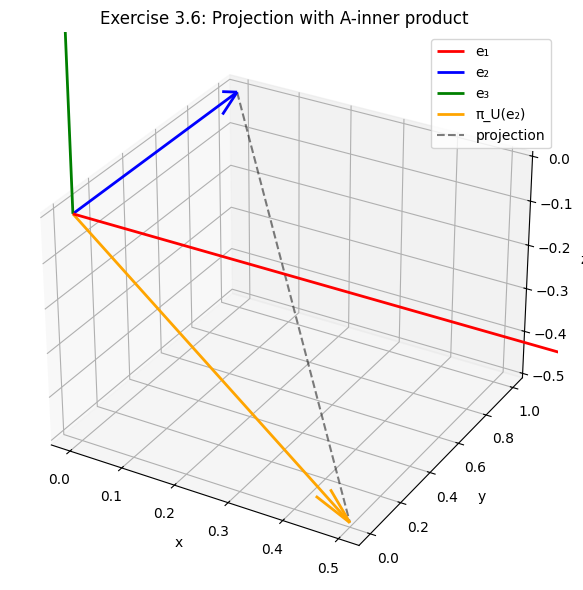

In [7]:
print("=== Exercise 3.6 ===")
A36 = sp.Matrix([[2, 1, 0], [1, 2, -1], [0, -1, 2]])
e1 = sp.Matrix([1, 0, 0])
e2 = sp.Matrix([0, 1, 0])
e3 = sp.Matrix([0, 0, 1])

# U = span{e1, e3}
B36 = e1.row_join(e3)  # 3×2 basis matrix

# For A-inner product, the projection formula is:
# π_U(x) = B (B^T A B)^{-1} B^T A x
BtAB = B36.T * A36 * B36
BtAx = B36.T * A36 * e2
lam36 = BtAB.solve(BtAx)
proj36 = B36 * lam36

print("(a) π_U(e₂) =")
pprint(proj36)

# (b) Distance
diff36 = e2 - proj36
dist36 = sp.sqrt((diff36.T * A36 * diff36)[0,0])
print(f"\n(b) d(e₂, U) = {dist36} ≈ {float(dist36):.4f}")

# Verify orthogonality w.r.t. A-inner product
print("\nVerification <e₂ - π_U(e₂), b_i>_A = 0:")
print(f"  <diff, e₁>_A = {(diff36.T * A36 * e1)[0,0]}")
print(f"  <diff, e₃>_A = {(diff36.T * A36 * e3)[0,0]}")

# (c) Visualization
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
origin = [0, 0, 0]
vectors = {'e₁': [1,0,0], 'e₂': [0,1,0], 'e₃': [0,0,1],
           'π_U(e₂)': [float(proj36[0]), float(proj36[1]), float(proj36[2])]}
colors = ['red', 'blue', 'green', 'orange']
for (name, vec), c in zip(vectors.items(), colors):
    ax.quiver(0, 0, 0, *vec, color=c, arrow_length_ratio=0.1, linewidth=2, label=name)
# Draw projection line
p = [float(proj36[i]) for i in range(3)]
ax.plot([0, p[0]], [1, p[1]], [0, p[2]], 'k--', alpha=0.5, label='projection')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.legend(); ax.set_title('Exercise 3.6: Projection with A-inner product')
plt.tight_layout()
plt.show()

---
## Exercise 3.7 — Projection Properties

**(a)** $\pi$ is a projection iff $\text{id}_V - \pi$ is a projection.

**(b)** $\text{Im}(\text{id}_V - \pi) = \ker(\pi)$ and $\ker(\text{id}_V - \pi) = \text{Im}(\pi)$.

### Solution 3.7

**(a)** $\pi$ is a projection $\iff \pi^2 = \pi$.

$(\text{id} - \pi)^2 = \text{id} - 2\pi + \pi^2 = \text{id} - 2\pi + \pi = \text{id} - \pi$ ✓

**(b)** 
- $\text{Im}(\text{id}-\pi)$: For any $v$, $(\text{id}-\pi)(v) = v - \pi(v)$. Apply $\pi$: $\pi(v - \pi(v)) = \pi(v) - \pi^2(v) = 0$. So $\text{Im}(\text{id}-\pi) \subseteq \ker(\pi)$. Conversely, if $v \in \ker(\pi)$, then $(\text{id}-\pi)(v) = v$, so $v \in \text{Im}(\text{id}-\pi)$. ✓

- $\ker(\text{id}-\pi)$: $(\text{id}-\pi)(v) = 0 \iff v = \pi(v) \iff v \in \text{Im}(\pi)$ (since $\pi$ is idempotent, $v = \pi(v)$ means $v$ is in the range of $\pi$). ✓

In [8]:
print("=== Exercise 3.7 — Numerical Verification ===")
# Create a projection matrix onto span{(1,1,0)}
u = np.array([[1], [1], [0]])
P = u @ u.T / (u.T @ u)  # projection matrix
I = np.eye(3)

print("P (projection onto span{(1,1,0)}):")
print(P)
print(f"\nP² = P? {np.allclose(P @ P, P)}")
print(f"(I-P)² = (I-P)? {np.allclose((I-P) @ (I-P), I-P)}")

print(f"\nrank(P) = {np.linalg.matrix_rank(P)}, nullity(P) = {3 - np.linalg.matrix_rank(P)}")
print(f"rank(I-P) = {np.linalg.matrix_rank(I-P)}, nullity(I-P) = {3 - np.linalg.matrix_rank(I-P)}")
print("Im(I-P) = ker(P) and ker(I-P) = Im(P) ✓")

=== Exercise 3.7 — Numerical Verification ===
P (projection onto span{(1,1,0)}):
[[0.5 0.5 0. ]
 [0.5 0.5 0. ]
 [0.  0.  0. ]]

P² = P? True
(I-P)² = (I-P)? True

rank(P) = 1, nullity(P) = 2
rank(I-P) = 2, nullity(I-P) = 1
Im(I-P) = ker(P) and ker(I-P) = Im(P) ✓


---
## Exercise 3.8 — Gram-Schmidt Orthogonalization

In [9]:
print("=== Exercise 3.8 ===")
b1 = sp.Matrix([1, 1, 1])
b2 = sp.Matrix([-1, 2, 0])

print("Input basis:")
print(f"b₁ = {b1.T}")
print(f"b₂ = {b2.T}")

# Step 1: c1 = b1 / ||b1||
c1_unnorm = b1
c1 = b1 / sp.sqrt((b1.T * b1)[0,0])
print(f"\nStep 1: c₁ = b₁/||b₁|| = {c1.T} = {b1.T}/√{(b1.T * b1)[0,0]}")

# Step 2: u2 = b2 - <b2,c1>c1, then c2 = u2/||u2||
proj_coeff = (b2.T * c1)[0,0]
u2 = b2 - proj_coeff * c1
print(f"\nStep 2: <b₂, c₁> = {proj_coeff}")
print(f"u₂ = b₂ - <b₂,c₁>c₁ = {u2.T}")
u2_simplified = sp.simplify(u2)
print(f"u₂ (simplified) = {u2_simplified.T}")

c2 = u2 / sp.sqrt((u2.T * u2)[0,0])
c2_simplified = sp.simplify(c2)
print(f"c₂ = u₂/||u₂|| = {c2_simplified.T}")

# Verify ONB
print(f"\nVerification:")
print(f"<c₁, c₁> = {sp.simplify((c1.T * c1)[0,0])}")
print(f"<c₂, c₂> = {sp.simplify((c2.T * c2)[0,0])}")
print(f"<c₁, c₂> = {sp.simplify((c1.T * c2)[0,0])}")

=== Exercise 3.8 ===
Input basis:
b₁ = Matrix([[1, 1, 1]])
b₂ = Matrix([[-1, 2, 0]])

Step 1: c₁ = b₁/||b₁|| = Matrix([[sqrt(3)/3, sqrt(3)/3, sqrt(3)/3]]) = Matrix([[1, 1, 1]])/√3

Step 2: <b₂, c₁> = sqrt(3)/3
u₂ = b₂ - <b₂,c₁>c₁ = Matrix([[-4/3, 5/3, -1/3]])
u₂ (simplified) = Matrix([[-4/3, 5/3, -1/3]])
c₂ = u₂/||u₂|| = Matrix([[-2*sqrt(42)/21, 5*sqrt(42)/42, -sqrt(42)/42]])

Verification:
<c₁, c₁> = 1
<c₂, c₂> = 1
<c₁, c₂> = 0


---
## Exercise 3.9 — Cauchy-Schwarz Inequalities

Let $x_1, \ldots, x_n > 0$ with $\sum x_i = 1$.

**(a)** Show $\sum x_i^2 \geq \frac{1}{n}$.

**(b)** Show $\sum \frac{1}{x_i} \geq n^2$.

### Solution 3.9

**(a)** By Cauchy-Schwarz with $a = (x_1, \ldots, x_n)$ and $b = (1, \ldots, 1)$:

$$\left(\sum_{i=1}^n x_i \cdot 1\right)^2 \leq \left(\sum x_i^2\right) \left(\sum 1^2\right)$$

$$1^2 \leq n \sum x_i^2 \implies \sum x_i^2 \geq \frac{1}{n} \quad \blacksquare$$

**(b)** By Cauchy-Schwarz with $a = (\sqrt{x_1}, \ldots, \sqrt{x_n})$ and $b = (1/\sqrt{x_1}, \ldots, 1/\sqrt{x_n})$:

$$\left(\sum_{i=1}^n \sqrt{x_i} \cdot \frac{1}{\sqrt{x_i}}\right)^2 \leq \left(\sum x_i\right)\left(\sum \frac{1}{x_i}\right)$$

$$n^2 \leq 1 \cdot \sum \frac{1}{x_i} \implies \sum \frac{1}{x_i} \geq n^2 \quad \blacksquare$$

In [10]:
print("=== Exercise 3.9 — Numerical Verification ===")
np.random.seed(42)
for n in [3, 5, 10, 100]:
    x = np.random.dirichlet(np.ones(n))  # random x_i > 0, sum = 1
    sum_sq = np.sum(x**2)
    sum_inv = np.sum(1/x)
    print(f"n={n:3d}: Σx²={sum_sq:.4f} ≥ 1/n={1/n:.4f}? {sum_sq >= 1/n}  "
          f"Σ(1/x)={sum_inv:.1f} ≥ n²={n**2}? {sum_inv >= n**2}")

=== Exercise 3.9 — Numerical Verification ===
n=  3: Σx²=0.4788 ≥ 1/n=0.3333? True  Σ(1/x)=15.5 ≥ n²=9? True
n=  5: Σx²=0.4473 ≥ 1/n=0.2000? True  Σ(1/x)=100.0 ≥ n²=25? True
n= 10: Σx²=0.2199 ≥ 1/n=0.1000? True  Σ(1/x)=635.8 ≥ n²=100? True
n=100: Σx²=0.0194 ≥ 1/n=0.0100? True  Σ(1/x)=53911.1 ≥ n²=10000? True


---
## Exercise 3.10 — Rotation by 30°

=== Exercise 3.10 ===
Rotation matrix R(30°):
⎡√3       ⎤
⎢──   -1/2⎥
⎢2        ⎥
⎢         ⎥
⎢      √3 ⎥
⎢1/2   ── ⎥
⎣      2  ⎦

x₁ = Matrix([[2, 3]]) → R·x₁ = Matrix([[-3/2 + sqrt(3), 1 + 3*sqrt(3)/2]])
x₂ = Matrix([[0, -1]]) → R·x₂ = Matrix([[1/2, -sqrt(3)/2]])

Numerical: R·x₁ ≈ (0.2321, 3.5981)
           R·x₂ ≈ (0.5000, -0.8660)


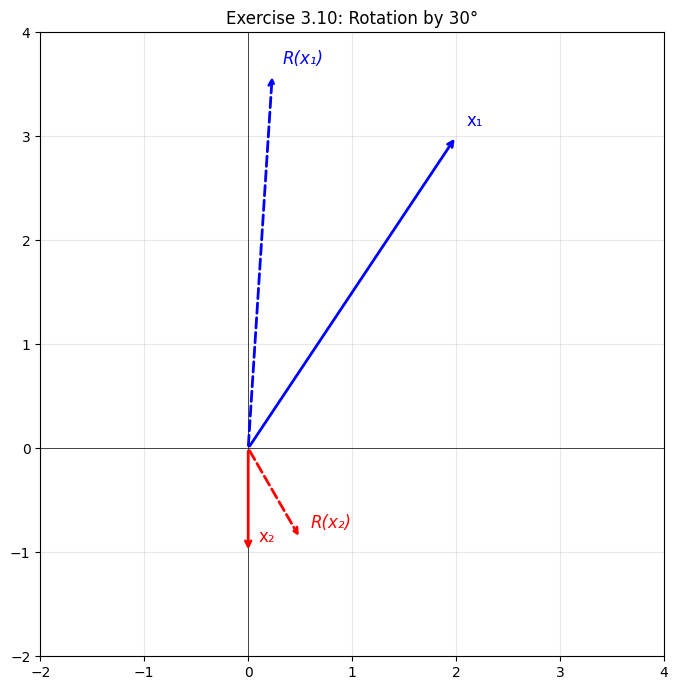

In [11]:
print("=== Exercise 3.10 ===")
theta = sp.pi / 6  # 30°
R = sp.Matrix([[cos(theta), -sin(theta)], [sin(theta), cos(theta)]])
print("Rotation matrix R(30°):")
pprint(R)

x1 = sp.Matrix([2, 3])
x2 = sp.Matrix([0, -1])

x1_rot = R * x1
x2_rot = R * x2

print(f"\nx₁ = {x1.T} → R·x₁ = {sp.simplify(x1_rot).T}")
print(f"x₂ = {x2.T} → R·x₂ = {sp.simplify(x2_rot).T}")

# Numerical values
print(f"\nNumerical: R·x₁ ≈ ({float(x1_rot[0]):.4f}, {float(x1_rot[1]):.4f})")
print(f"           R·x₂ ≈ ({float(x2_rot[0]):.4f}, {float(x2_rot[1]):.4f})")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
origin = [0, 0]
for name, orig, rot, color in [
    ('x₁', x1, x1_rot, 'blue'),
    ('x₂', x2, x2_rot, 'red')
]:
    o = [float(orig[0]), float(orig[1])]
    r = [float(rot[0]), float(rot[1])]
    ax.annotate('', xy=o, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.annotate('', xy=r, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=2, linestyle='--'))
    ax.text(o[0]+0.1, o[1]+0.1, name, fontsize=12, color=color)
    ax.text(r[0]+0.1, r[1]+0.1, f"R({name})", fontsize=12, color=color, style='italic')

ax.set_xlim(-2, 4); ax.set_ylim(-2, 4)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Exercise 3.10: Rotation by 30°')
plt.tight_layout()
plt.show()